# petekIO — well analysis: zones, net cutoffs & the correlation view

From loaded wells to a reservoir-quality summary: zone tables in stratigraphic
order, thickness-weighted averages, an A/B **net-cutoff** sweep, and the standalone
log-correlation view. Data is **synthetic** (hand-authored, no real data) — the
same field as the ingest tour.

## Author & load the field

(Same self-contained synthetic field as `01_ingest_tour`: a multi-bore well
`25/1-1`, a single-bore `25/1-2`, PHIE / SW / VSH logs, monotonic tops.)

In [1]:
import math, random, tempfile
from pathlib import Path
import petekio


def _write(p, body):
    p = Path(p); p.parent.mkdir(parents=True, exist_ok=True); p.write_text(body); return p


def write_wellpath(p, head, kb, stations):
    """A positioned Petrel `.wellpath` (vertical here): rows are MD X Y Z TVD ..."""
    rows = "".join(f"{md} {x} {y} {z} {md} 0 0 0 0 0 0\n" for md, x, y, z in stations)
    return _write(p, ("# WELL TRACE FROM PETREL\n"
        f"# WELL HEAD X-COORDINATE: {head[0]} (m)\n# WELL HEAD Y-COORDINATE: {head[1]} (m)\n"
        f"# WELL DATUM (KB, Kelly bushing, from MSL): {kb} (m)\n# CRS: ED50 / UTM zone 31N\n=====\n"
        "MD X Y Z TVD DX DY AZIM_TN INCL DLS AZIM_GN\n" + rows))


def write_las(p, curves, samples):
    """A LAS 2.0 file: a depth index plus one column per (mnemonic, unit)."""
    strt, stop = samples[0][0], samples[-1][0]
    hdr = "".join(f" {m}.{u} :\n" for m, u in curves)
    rows = "".join(" ".join(f"{v:.4f}" for v in row) + "\n" for row in samples)
    return _write(p, ("~Version\n VERS. 2.0 :\n WRAP. NO :\n"
        f"~Well\n STRT.M {strt} :\n STOP.M {stop} :\n STEP.M 0 :\n NULL. -999.25 :\n"
        f"~Curve\n DEPT.M :\n{hdr}~ASCII\n" + rows))


def write_tops(p, rows):
    """A Petrel multi-well tops file. `rows` = (md, surface, well)."""
    hdr = ("# Petrel well tops\nVERSION 2\nBEGIN HEADER\n"
           "X\nY\nZ\nTWT\nTWT2\nage\nMD\nPVD\nType\nSurface\nWell\nEND HEADER\n")
    body = "".join(f'1 2 -1 -999 -999 -999 {md} -1 Horizon "{s}" "{w}"\n' for md, s, w in rows)
    return _write(p, hdr + body)


def write_irap(p, xori, yori, xinc, yinc, ncol, nrow, fn):
    """An IRAP-classic ASCII surface; `fn(i, j)` -> depth (NaN = undefined)."""
    undef = 9999900.0
    xmax, ymax = xori + (ncol - 1) * xinc, yori + (nrow - 1) * yinc
    lines = [f"-996 {nrow} {xinc} {yinc}", f"{xori} {xmax} {yori} {ymax}",
             f"{ncol} 0 {xori} {yori}", "0  0  0  0  0  0  0"]
    toks = [(f"{undef:.6f}" if (v := fn(i, j)) != v else f"{v:.6f}")
            for j in range(nrow) for i in range(ncol)]
    for k in range(0, len(toks), 6):
        lines.append(" ".join(toks[k:k + 6]))
    return _write(p, "\n".join(lines) + "\n")


# The intended column, shallow -> deep: (name, md-below-datum, phi, sw, vsh).
_COLUMN = [("Top Reservoir", 0, 0.06, 0.85, 0.42), ("Upper Sand", 40, 0.24, 0.28, 0.10),
           ("Mid Sand", 80, 0.27, 0.20, 0.08), ("Lower Sand", 120, 0.19, 0.45, 0.22),
           ("Base Reservoir", 170, 0.08, 0.90, 0.45)]


def _samples(base, step, seed, phi_bias=0.0):
    """PHIE / SW / VSH down a hole: each zone's modelled values + a little noise."""
    rng = random.Random(seed); md = base - 30; out = []
    tops = [(n, base + d) for n, d, *_ in _COLUMN]
    while md <= base + 190:
        phi, sw, vsh = 0.05, 0.95, 0.5
        for n, d, p, s, v in _COLUMN:
            if md >= base + d:
                phi, sw, vsh = p, s, v
        out.append((md, max(0.0, phi + phi_bias + rng.uniform(-0.01, 0.01)),
                    min(1.0, max(0.0, sw + rng.uniform(-0.03, 0.03))),
                    max(0.0, vsh + rng.uniform(-0.02, 0.02))))
        md += step
    return out, tops


def make_field(out_dir):
    """Write a small SYNTHETIC field under `out_dir`; return the key paths.

    Two wells: `25/1-1` is multi-bore (bore A sampled fine, bore B coarse and
    biased low, so thickness-weighting visibly matters); `25/1-2` is single-bore.
    Plus two depth surfaces (a gentle dome) and a scattered-point CSV.
    """
    out = Path(out_dir); C = [("PHIE", "m3/m3"), ("SW", "m3/m3"), ("VSH", "m3/m3")]
    top_rows = []
    for bore, step, seed, bias in [("A", 0.5, 1, 0.0), ("B", 1.5, 2, -0.05)]:
        base = 2000.0
        write_wellpath(out / "wells" / "25_1-1" / f"25_1-1_{bore}.wellpath", (1000.0, 5000.0),
                       25.0, [(base - 40, 1000.0, 5000.0, -(base - 40)),
                              (base + 200, 1000.0, 5000.0, -(base + 200))])
        s, tops = _samples(base, step, seed, bias)
        write_las(out / "wells" / "25_1-1" / f"25_1-1_{bore}_logs.las", C, s)
        top_rows += [(md, n, f"25/1-1 {bore}") for n, md in tops]
    base = 2120.0
    write_wellpath(out / "wells" / "25_1-2" / "25_1-2.wellpath", (3000.0, 5200.0), 30.0,
                   [(base - 40, 3000.0, 5200.0, -(base - 40)), (base + 200, 3000.0, 5200.0, -(base + 200))])
    s, tops = _samples(base, 0.5, 3)
    write_las(out / "wells" / "25_1-2" / "25_1-2_logs.las", C, s)
    top_rows += [(md, n, "25/1-2") for n, md in tops]
    tp = write_tops(out / "tops" / "field.tops", top_rows)
    top = write_irap(out / "surfaces" / "top_res.irap", 0.0, 0.0, 50.0, 50.0, 40, 30,
                     lambda i, j: 2000.0 - 60.0 * math.exp(-(((i - 20) / 9) ** 2 + ((j - 15) / 7) ** 2)))
    base_s = write_irap(out / "surfaces" / "base_res.irap", 0.0, 0.0, 50.0, 50.0, 40, 30,
                        lambda i, j: 2060.0 - 55.0 * math.exp(-(((i - 20) / 9) ** 2 + ((j - 15) / 7) ** 2)))
    rng = random.Random(7)
    pts = "x,y,depth,poro\n" + "".join(
        f"{rng.uniform(0, 1950):.1f},{rng.uniform(0, 1450):.1f},"
        f"{2000 - 55 * math.exp(-(((rng.random() - .5) * 3) ** 2)):.2f},{rng.uniform(0.05, 0.30):.3f}\n"
        for _ in range(60))
    _write(out / "points" / "scatter.csv", pts)
    return {"root": out, "wells_dir": out / "wells", "tops": tp,
            "top_surface": top, "base_surface": base_s, "points": out / "points" / "scatter.csv"}


# Write the field into a throwaway temp directory and confirm the tree.
field = make_field(tempfile.mkdtemp())
sorted(str(p.relative_to(field["root"])) for p in field["root"].rglob("*") if p.is_file())

['points/scatter.csv',
 'surfaces/base_res.irap',
 'surfaces/top_res.irap',
 'tops/field.tops',
 'wells/25_1-1/25_1-1_A.wellpath',
 'wells/25_1-1/25_1-1_A_logs.las',
 'wells/25_1-1/25_1-1_B.wellpath',
 'wells/25_1-1/25_1-1_B_logs.las',
 'wells/25_1-2/25_1-2.wellpath',
 'wells/25_1-2/25_1-2_logs.las']

In [2]:
geo = petekio.GeoData(unit="m")
for wid in ["25/1-1", "25/1-2"]:
    geo.load_well(wid, files=str(field["wells_dir"]))
geo.load_well_tops(str(field["tops"]))
print("strat column:", geo.strat_order)

strat column: ['Top Reservoir', 'Upper Sand', 'Mid Sand', 'Lower Sand', 'Base Reservoir']


## Zone table — tidy, ordered, thickness-weighted

`zone_table` assembles a pandas frame with zones as an **ordered** categorical
(lithostratigraphic order). `aggregate=True` adds a pooled `all` row per zone before
each bore; `gross` is the zone's MD thickness, `samples` the count.

In [3]:
w = geo.well("25/1-1")
w.zone_table("PHIE", stats=["mean", "gross", "samples"], aggregate=True, decimals=3)

mean  gross  samples
zone           bore                       
Top Reservoir  all   0.035   40.0    107.0
               A     0.060   40.0     80.0
               B     0.009   40.0     27.0
Upper Sand     all   0.214   40.0    107.0
               A     0.241   40.0     80.0
               B     0.189   40.0     27.0
Mid Sand       all   0.247   40.0    106.0
               A     0.272   40.0     80.0
               B     0.221   40.0     26.0
Lower Sand     all   0.166   50.0    134.0
               A     0.191   50.0    100.0
               B     0.142   50.0     34.0
Base Reservoir all   0.056   30.0     54.0
               A     0.081   30.0     41.0
               B     0.031   30.0     13.0

### Why thickness-weighting matters

Bore B is sampled coarsely and reads lower. The plain sample mean is dominated by
the densely-sampled bore A; the thickness-weighted mean (the default) treats each
bore by the rock it covers.

In [4]:
import pandas as pd
wt = w.zone_table("PHIE", aggregate=True)["mean"].xs("all", level="bore")
pl = w.zone_table("PHIE", aggregate=True, weighted=False)["mean"].xs("all", level="bore")
pd.DataFrame({"thickness-weighted": wt, "plain mean": pl}).round(3)

,thickness-weighted,plain mean
zone,,
Top Reservoir,0.035,0.047
Upper Sand,0.214,0.227
Mid Sand,0.247,0.259
Lower Sand,0.166,0.178
Base Reservoir,0.056,0.069


## An A/B net-cutoff sweep — `NetSettings`

`NetSettings` is the φ / Sw / Vsh net/pay cutoff spec. Pool only the samples that
pass, then compare two scenarios: a permissive **base** case and a **strict** one
derived with `.replace(...)`.

In [5]:
base = petekio.NetSettings(phi_min=0.08, sw_max=0.6)
strict = base.replace(phi_min=0.22, sw_max=0.4)
print(base)
print(strict)

NetSettings
  phi_min  >=  0.080
  sw_max   <=  0.600
  vsh_max  <=  0.500
NetSettings
  phi_min  >=  0.220
  sw_max   <=  0.400
  vsh_max  <=  0.500


In [6]:
b2 = geo.well("25/1-2").sidetrack("")

def net_means(cut):
    return {z: (round(st.mean, 3) if st.count else None) for z, st in b2.net_zone_stats("PHIE", cut=cut)}

pd.DataFrame({"base (φ≥0.08, Sw≤0.6)": net_means(base),
              "strict (φ≥0.22, Sw≤0.4)": net_means(strict)})

,"base (φ≥0.08, Sw≤0.6)","strict (φ≥0.22, Sw≤0.4)"
Top Reservoir,NaN,NaN
Upper Sand,0.240,0.240
Mid Sand,0.271,0.271
Lower Sand,0.190,NaN
Base Reservoir,NaN,NaN


The strict cutoff drops the tighter zones entirely (they no longer contribute a
net sample), while the clean sands survive — exactly the sensitivity an A/B sweep is
for. The same `cut=` conditions a `zone_table` cell-by-cell:

In [7]:
w.zone_table("PHIE", cut=strict, stats=["mean", "samples"], decimals=3)

,zone,bore,mean,samples
0,Upper Sand,A,0.241,80.0
1,Mid Sand,A,0.272,80.0
2,Mid Sand,B,0.226,15.0


## The log-correlation view

A well builds a self-contained log-correlation bundle from its own logs +
trajectory and renders it (the viewer is an optional dependency, imported lazily).
Here we export one standalone HTML file with `save=` — `view()` returns a
`LogSession` and writes the file.

In [8]:
import os, tempfile
html = os.path.join(tempfile.mkdtemp(), "well_25_1-2.html")
session = geo.well("25/1-2").view(curves=("PHIE", "SW", "VSH"), tops=True, save=html)
print("wrote", os.path.basename(html), f"({os.path.getsize(html)} bytes) —",
      "a self-contained, interactive correlation panel")

wrote well_25_1-2.html (1485109 bytes) — a self-contained, interactive correlation panel


### A static preview

The saved HTML is the interactive artifact; a headless-browser screenshot isn't
available in this environment, so we render a small static log-correlation panel
with matplotlib straight from the same log values and zone boundaries.

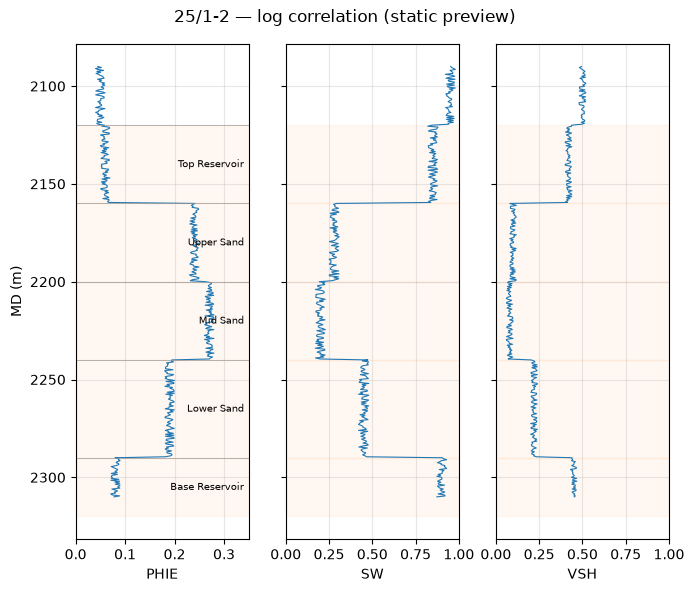

In [9]:
import matplotlib.pyplot as plt

b = geo.well("25/1-2").sidetrack("")
md = b.log("PHIE").md()
zones = b.zones()

fig, axes = plt.subplots(1, 3, figsize=(7, 6), sharey=True)
for ax, (curve, lo, hi) in zip(axes, [("PHIE", 0, 0.35), ("SW", 0, 1), ("VSH", 0, 1)]):
    ax.plot(b.log(curve).values(), md, lw=0.8)
    ax.set_xlim(lo, hi); ax.set_xlabel(curve); ax.grid(alpha=0.3)
    for name, top_md, base_md in zones:
        ax.axhspan(top_md, base_md, color="tab:orange", alpha=0.05)
axes[0].set_ylabel("MD (m)")
for _, top_md, _ in zones:
    axes[0].axhline(top_md, color="0.6", lw=0.5)
for name, top_md, base_md in zones:
    axes[0].text(0.34, (top_md + base_md) / 2, name, va="center", ha="right", fontsize=7)
axes[0].invert_yaxis()
fig.suptitle("25/1-2 — log correlation (static preview)")
fig.tight_layout()
plt.show()

## Recap

Zone tables in stratigraphic order, thickness-weighted by default; a two-scenario
net-cutoff sweep with `NetSettings`; and a self-contained correlation view exported
to HTML. Everything reads off the same loaded `GeoData` — the data layer does the
groundwork so the analysis stays short.